# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
from statsmodels.tsa.vector_ar.var_model import VAR
import complex_granger_analisys.src.complex_granger_analisys as CGA

2026-01-12 18:53:53.902524: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1768240436.486356  310146 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4057 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


In [2]:
type(pd.DataFrame())

pandas.core.frame.DataFrame

# F1 fault

In [3]:
#Załaduj dane
dane=pd.read_csv("fault_sensitivity-main/fault_sensitivity-main/data/f1_myex4.csv",sep=";",index_col='Unnamed: 0')
dane2=pd.read_csv("fault_sensitivity-main/fault_sensitivity-main/data/f2_myex4.csv",sep=";",index_col='Unnamed: 0')
data_df = pd.concat([dane,dane2], ignore_index=True)
data_df = data_df.drop(data_df.columns[data_df.var()<=0], axis=1)
data_df=data_df.dropna()
data_df.rename(columns={'u': 'z'}, inplace=True)

In [4]:
dane.shift(1)

,x1,x2,u1,e1,u,f1,f2
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.000259,0.015492,0.046253,0.997807,0.989189,0.0,0.0
3,-0.005809,0.031458,0.091250,0.989298,1.016789,0.0,0.0
4,0.013939,-0.013906,0.105426,1.020242,1.009915,0.0,0.0
5,0.074378,-0.024593,0.120791,0.995992,1.033317,0.0,0.0
...,...,...,...,...,...,...,...
495,1.149392,2.816769,1.238262,0.097656,1.274545,1.0,0.0
496,1.137579,2.801687,1.242162,0.124467,1.260327,1.0,0.0
497,1.162919,2.819770,1.244304,0.122025,1.254574,1.0,0.0
498,1.139332,2.819220,1.244924,0.089349,1.275780,1.0,0.0


In [5]:
dane=dane.drop(dane.columns[dane.var()<=0], axis=1)
dane2=dane2.drop(dane2.columns[dane2.var()<=0], axis=1)
dane.dropna()
dane2.dropna()

,x1,x2,u1,e1,u,f2
1,0.020557,-0.012704,0.047027,0.988477,1.017010,0.0
2,0.035821,0.013486,0.093017,0.996749,1.019115,0.0
3,0.015800,-0.002143,0.107260,0.984759,1.050014,0.0
4,0.056118,-0.002287,0.125701,1.034771,1.073559,0.0
5,0.162384,-0.021739,0.141852,1.017921,1.080603,0.0
...,...,...,...,...,...,...
495,67.855508,169.457499,13.574969,-66.604212,1.265614,1.0
496,67.873295,169.452671,13.576875,-66.589501,1.256087,1.0
497,67.889763,169.448503,13.576237,-66.617706,1.278104,1.0
498,67.881291,169.451327,13.577168,-66.612047,1.303963,1.0


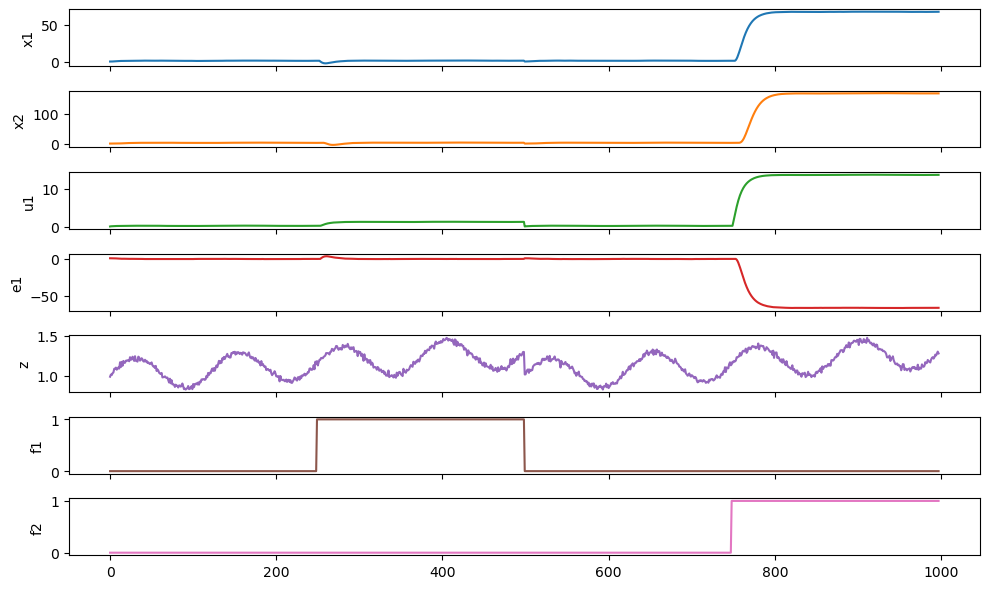

In [6]:
fig,ax = plt.subplots(len(data_df.columns), figsize=(10,6), sharex=True)
plot_cols = data_df.columns
data_df[plot_cols].plot(subplots=True, legend=False, ax=ax)
for a in range(len(ax)): 
    ax[a].set_ylabel(plot_cols[a])
ax[-1].set_xlabel('')
plt.tight_layout()
#plt.show()
plt.savefig('Ex5.svg', format='svg')

In [7]:
#Obserwowanie zależności własnej (sam od siebie)
def lag_plots(data_df):
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    lag_plot(data_df[data_df.columns[0]], ax=ax1)
    ax1.set_title(data_df.columns[0]);

    lag_plot(data_df[data_df.columns[1]], ax=ax2)
    ax2.set_title(data_df.columns[1]);

    ax1.set_ylabel('$y_{t+1}$');
    ax1.set_xlabel('$y_t$');
    ax2.set_ylabel('$y_{t+1}$');
    ax2.set_xlabel('$y_t$');

    plt.tight_layout()

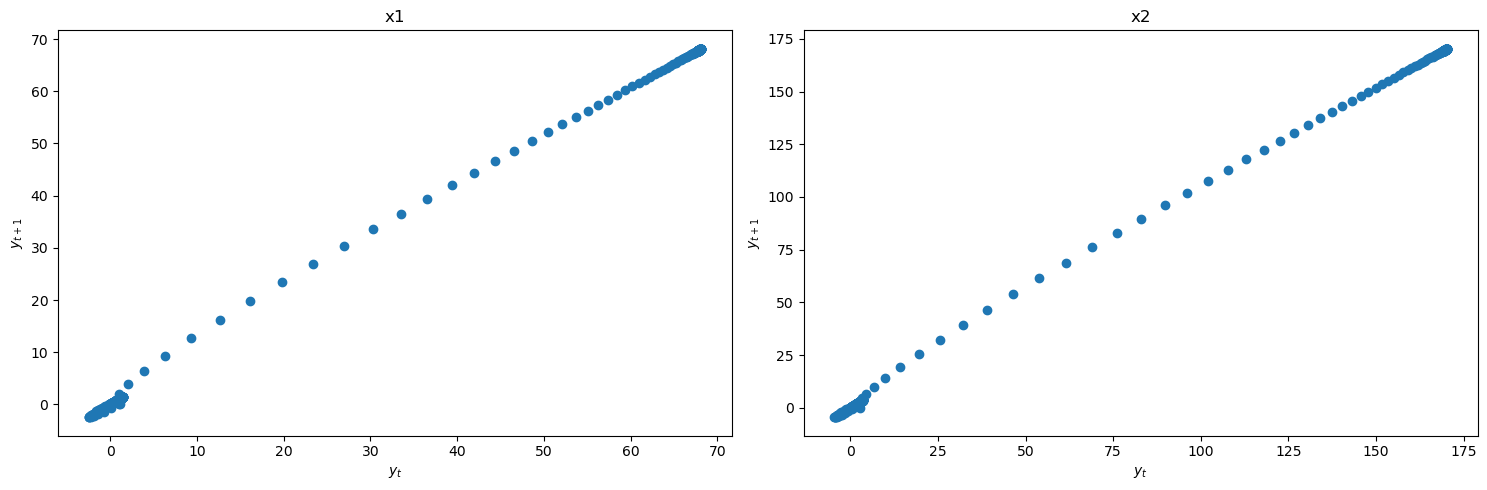

In [8]:
lag_plots(data_df)

### Sukanie optymalnego opóźnienia

In [9]:
def select_p(train_df,lag_max):
    aic, bic, fpe, hqic = [], [], [], []
    model = VAR(train_df) 
    p = np.arange(1,lag_max)
    for i in p:
        result = model.fit(i)
        aic.append(result.aic)
        bic.append(result.bic)
        fpe.append(result.fpe)
        hqic.append(result.hqic)
    lags_metrics_df = pd.DataFrame({'AIC': aic, 
                                    'BIC': bic, 
                                    'HQIC': hqic,
                                    'FPE': fpe
                                    }, 
                                   index=p)    
    fig, ax = plt.subplots(1, 4, figsize=(15, 3), sharex=True)
    lags_metrics_df.plot(subplots=True, ax=ax, marker='o')
    plt.tight_layout()
    print(lags_metrics_df.idxmin(axis=0))

AIC     5
BIC     4
HQIC    5
FPE     5
dtype: int64


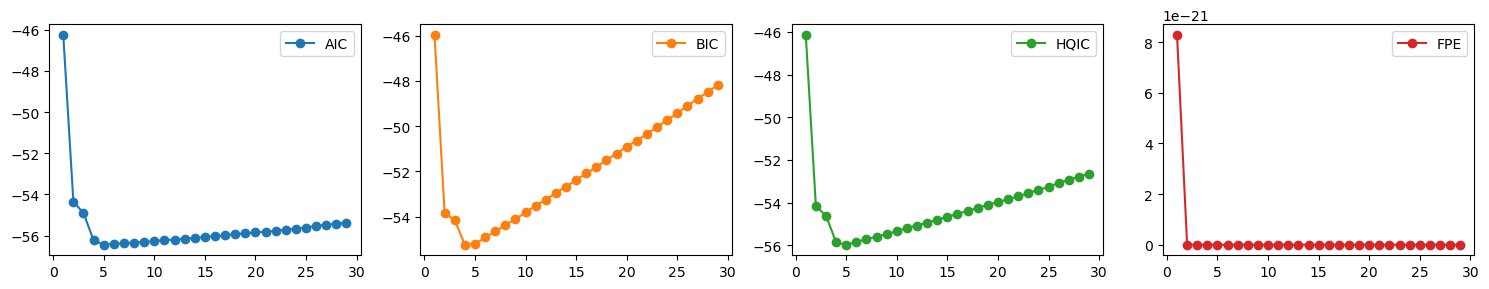

In [10]:
select_p(data_df,30)

## Classical Grangera Analysis

In [11]:
CGA.grangers_causation_matrix(data_df.copy(),test="ssr_ftest",effects=data_df.columns[:-5].to_list()+data_df.columns[-3:].to_list(),causes=data_df.columns[:-5].to_list()+data_df.columns[-3:].to_list())

/home/janek/miniconda3/envs/tf/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/janek/miniconda3/envs/tf/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/tf/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/tf/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/tf/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecat

,x1_x,x2_x,z_x,f1_x,f2_x
x1_y,0.0,-1.0,-1.0,-1.0,1.0
x2_y,1.0,0.0,-1.0,-1.0,1.0
z_y,0.0,0.0,0.0,1.0,0.0
f1_y,0.0,0.0,0.0,0.0,0.0
f2_y,0.0,0.0,0.0,0.0,0.0


# Multivariable Grangera Analisys

### Scikit-learn matrix gradient regresion

In [ ]:
GCskit=CGA.SparseConstaraintedMVGC(cycle_lasso=True)#writer=True,writer_outdir="logs/fit/")
GCskit.fit(data_df)
GCskit.results.result()
#25.9
#17.9

,x1,x2,u1,e1,z,f1,f2
x1,0,1,1,0,0,1,0
x2,0,1,0,1,0,0,0
u1,0,0,1,0,0,0,1
e1,1,0,0,0,0,0,0
z,0,0,0,0,1,0,0
f1,0,0,0,0,0,0,0
f2,0,0,0,0,0,0,0


In [29]:
GCskit2=CGA.SparseConstaraintedMVGC()#writer=True,writer_outdir="logs/fit/")
GCskit2.fit(data_df,causes=['f1','f2'])
GCskit2.results.result()


,f1,f2
x1,1,1
x2,1,0
u1,1,1
e1,0,0
z,0,0
f1,0,0
f2,0,0


In [30]:
# GCskit2=CGA.SparseConstaraintedMVGC(sparse=-1)
# GCskit2.fit(data_df)
# GCskit2.results.result()
# #1 7.3
# #51.1

### Tensorflow matrix gradient regresion

In [32]:
GCANN=CGA.TFNeuralSparseConstaraintedMVGC(sparse=1e-4)
GCskit.with_zero_lag=True
GCANN.fit(data_df)
GCANN.results.result()
# 4 44.7
# 3 11.9

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


,x1,x2,u1,e1,z,f1,f2
x1,1,0,1,0,0,1,1
x2,0,1,0,1,0,0,0
u1,0,0,1,0,0,1,1
e1,1,0,1,0,1,1,0
z,0,0,0,0,1,0,0
f1,0,0,0,0,0,0,0
f2,0,0,0,0,0,0,0


### Pytorch

In [ ]:
GCANN2=CGA.PTNeuralSparseConstaraintedMVGC()
GCANN2.fit(data_df)
GCANN2.results.result()

AttributeError: module 'complex_granger_analisys.src.complex_granger_analisys' has no attribute 'PTNeuralSparseConstaraintedMVGC'

# Cześć dalasza

In [ ]:
#pd.concat([SparseGrangerMatirx2D(dane,sparse=0.),SparseGrangerMatirx2D(dane2,sparse=0.,causes=['f2'])], axis=1)
#6.7
#pd.concat([SparseGrangerMatirxANN(dane,sparse=0.),SparseGrangerMatirxANN(dane2,sparse=0.,causes=['f2'])], axis=1)
#1 1.1
#pd.concat([SparseGrangerMatirx2D(dane,sparse=-1.),SparseGrangerMatirx2D(dane2,sparse=-1.,causes=['f2'])], axis=1)
#23.4
#pd.concat([SparseGrangerMatirxANN(dane,sparse=-1.),SparseGrangerMatirxANN(dane2,sparse=-1.,causes=['f2'])], axis=1)
#1 5.3

In [ ]:
#SparseGrangerMatirx2D(data_df,sparse=0.,relation={('x1','z'):0,('x2','e1'):0})#,('u1','u1'):0})
#SparseGrangerMatirxANN(data_df,sparse=-1.,relation={('x1','z'):0,('x2','e1'):0})